In [1]:
pip install emoji vncorenlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 111.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 53.6 MB/s eta 0:00:00
  Created wheel for vncorenlp: filename=vncorenlp-1.0.3-py3-none-any.whl size=2645933 sha256=1a2da37daa81a09f5a6fd9dbcf57c833fcf90f4a5f03a923d11abc520fd76978
  Stored in directory: /root/.cache/pip/wheels/6f/19/20/ec7083125fd06db1a19d0d3ca18806ecf4e8ed1464713b4efa
Successfully built vncorenlp


In [2]:
import html
import inspect
import random
import re
import unicodedata
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Sequence
from urllib.request import urlretrieve

import emoji
import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from vncorenlp import VnCoreNLP


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Config

In [33]:
run_name = "vlsp-2018-hotel-e5-small"
train_csv_path = Path("/content/drive/MyDrive/bachnt/KHDL/vlsp2018_hotel/1-VLSP2018-SA-Hotel-train.csv")
val_csv_path = Path("/content/drive/MyDrive/bachnt/KHDL/vlsp2018_hotel/2-VLSP2018-SA-Hotel-dev.csv")
test_csv_path = Path("/content/drive/MyDrive/bachnt/KHDL/vlsp2018_hotel/3-VLSP2018-SA-Hotel-test.csv")
pretrained_model_name = "intfloat/multilingual-e5-small"


In [34]:
epochs = 20
batch_size = 21
max_length = 256
learning_rate = 2e-4
weight_decay = 0.0
warmup_ratio = 0.1
early_stopping_patience = 7
early_stopping_min_delta = 0.0
num_workers = 0
multi_branch = False
use_text_preprocessing = True
use_word_segmentation = False
seed = 42

output_dir = Path("/content/drive/MyDrive/bachnt/KHDL/checkpoints")
prediction_dir = Path("/content/drive/MyDrive/bachnt/KHDL/predictions")


# Preprocess

## Label Mapping


In [36]:
class PolarityMapping:
    INDEX_TO_POLARITY = {0: None, 1: "positive", 2: "negative", 3: "neutral"}
    POLARITY_TO_INDEX = {None: 0, "positive": 1, "negative": 2, "neutral": 3}


##  Word Segmentation Resources


In [37]:
VNCORENLP_BASE_URL = "https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master"
VNCORENLP_FILES = [
    "VnCoreNLP-1.2.jar",
    "models/wordsegmenter/vi-vocab",
    "models/wordsegmenter/wordsegmenter.rdr",
]
TEENCODE_URL = "https://gist.githubusercontent.com/nguyenvanhieuvn/7d9441c10b3c2739499fc5a4d9ea06fb/raw/df939245b3e841b62af115be4dcb3516dadc9fc5/teencode.txt"
ACRONYM_MAP: dict[str, str] | None = None
WORD_SEGMENTER: VnCoreNLP | None = None


def ensure_vncorenlp(vncorenlp_dir: str | Path = "VnCoreNLP") -> Path:
    vncorenlp_dir = Path(vncorenlp_dir)
    for relative_path in VNCORENLP_FILES:
        local_path = vncorenlp_dir / relative_path
        if local_path.exists():
            continue
        local_path.parent.mkdir(parents=True, exist_ok=True)
        url = f"{VNCORENLP_BASE_URL}/{relative_path}"
        print(f"Downloading {url} -> {local_path}")
        urlretrieve(url, local_path)
    return vncorenlp_dir


def get_word_segmenter() -> VnCoreNLP:
    global WORD_SEGMENTER
    if WORD_SEGMENTER is None:
        vncorenlp_dir = ensure_vncorenlp()
        WORD_SEGMENTER = VnCoreNLP(
            str(vncorenlp_dir / "VnCoreNLP-1.2.jar"),
            annotators="wseg",
            quiet=True,
        )
    return WORD_SEGMENTER


## Text Cleaning


In [38]:
def build_acronym_map(teencode_path: str | Path = "teencode.txt") -> dict[str, str]:
    teencode_path = Path(teencode_path)
    mapping = {
        "okie": "ok",
        "okey": "ok",
        "oki": "ok",
        "oke": "ok",
        "okê": "ok",
        "kg": "không",
        "k": "không",
        "kh": "không",
        "ko": "không",
        "khong": "không",
        "kp": "không phải",
        "tks": "cảm ơn",
        "thks": "cảm ơn",
        "thanks": "cảm ơn",
        "ths": "cảm ơn",
        "mún": "muốn",
        "thik": "thích",
        "wa": "quá",
        "wá": "quá",
        "qá": "quá",
        "đc": "được",
        "dc": "được",
        "dk": "được",
        "đk": "được",
        "vs": "với",
        "j": "gì",
        "r": "rồi",
        "nv": "nhân viên",
    }
    if not teencode_path.exists():
        try:
            print(f"Downloading {TEENCODE_URL} -> {teencode_path}")
            urlretrieve(TEENCODE_URL, teencode_path)
        except Exception as exc:
            print(f"Could not download teencode list: {exc}")
    if teencode_path.exists():
        for line in teencode_path.read_text(encoding="utf-8").splitlines():
            if "	" not in line:
                continue
            teencode, normalized = line.split("	", 1)
            mapping[teencode.strip().lower()] = normalized.strip()
    return mapping


def normalize_acronyms(text: str) -> str:
    global ACRONYM_MAP
    if ACRONYM_MAP is None:
        ACRONYM_MAP = build_acronym_map()
    return " ".join(ACRONYM_MAP.get(word.lower(), word) for word in text.split())


def remove_HTML(text: str) -> str:
    text = html.unescape(str(text))
    return re.sub(r"<[^>]+>", " ", text)


def convert_unicode(text: str) -> str:
    return unicodedata.normalize("NFC", text)


def word_segmentation(text: str) -> str:
    sentences = get_word_segmenter().tokenize(text)
    return " ".join(token for sentence in sentences for token in sentence)


def remove_unnecessary_characters(text: str) -> str:
    text = emoji.replace_emoji(text, " ")
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    return re.sub(r"\s+", " ", text).strip()


def text_preprocess(text: str, use_word_segmentation: bool = False) -> str:
    text = remove_HTML(text)
    text = convert_unicode(text)
    text = normalize_acronyms(text)
    if use_word_segmentation:
        text = word_segmentation(text)
    return remove_unnecessary_characters(text)


# Dataset


In [39]:
def infer_aspect_category_names(csv_path: str | Path) -> list[str]:
    columns = pd.read_csv(csv_path, nrows=0).columns.tolist()
    return [column for column in columns if column != "Review"]


class ABSACsvDataset(Dataset):
    def __init__(
        self,
        csv_path: str | Path,
        aspect_category_names: Sequence[str] | None = None,
        text_preprocessor=None,
    ) -> None:
        self.csv_path = Path(csv_path)
        self.frame = pd.read_csv(self.csv_path)
        self.aspect_category_names = list(aspect_category_names or infer_aspect_category_names(self.csv_path))
        self.raw_texts = self.frame["Review"].astype(str).tolist()
        if text_preprocessor is None:
            self.texts = self.raw_texts
        else:
            self.texts = [
                text_preprocessor(text)
                for text in tqdm(self.raw_texts, desc=f"preprocess {self.csv_path.name}", leave=False)
            ]
        self.labels = self.frame[self.aspect_category_names].fillna(0).astype("int64").to_numpy()

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int) -> dict[str, object]:
        return {"text": self.texts[index], "labels": self.labels[index]}


## Collator And Dataloaders


In [40]:
@dataclass
class ABSACollator:
    tokenizer: object
    max_length: int = 256

    def __call__(self, examples: list[dict[str, object]]) -> dict[str, torch.Tensor]:
        texts = [str(example["text"]) for example in examples]
        labels = torch.tensor(np.stack([example["labels"] for example in examples]), dtype=torch.long)
        encoded = self.tokenizer(
            texts,
            max_length=self.max_length,
            padding=True,
            truncation=True,
            return_tensors="pt",
        )
        encoded["labels"] = labels
        return encoded


def build_dataloaders(
    train_csv_path: str | Path,
    val_csv_path: str | Path,
    test_csv_path: str | Path,
    tokenizer: object,
    batch_size: int = 8,
    max_length: int = 256,
    num_workers: int = 0,
    text_preprocessor=None,
) -> tuple[dict[str, DataLoader], list[str]]:
    paths = {
        "train": Path(train_csv_path),
        "val": Path(val_csv_path),
        "test": Path(test_csv_path),
    }
    aspect_category_names = infer_aspect_category_names(paths["train"])
    collator = ABSACollator(tokenizer=tokenizer, max_length=max_length)
    datasets = {
        split: ABSACsvDataset(
            path,
            aspect_category_names=aspect_category_names,
            text_preprocessor=text_preprocessor,
        )
        for split, path in paths.items()
    }
    loaders = {
        "train": DataLoader(datasets["train"], batch_size=batch_size, shuffle=True, num_workers=num_workers, collate_fn=collator),
        "val": DataLoader(datasets["val"], batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=collator),
        "test": DataLoader(datasets["test"], batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=collator),
    }
    return loaders, aspect_category_names


# Model

In [41]:
class TransformerABSA(nn.Module):
    def __init__(
        self,
        pretrained_model_name: str,
        aspect_category_names: Iterable[str],
        multi_branch: bool = False,
        dropout: float = 0.2,
    ) -> None:
        super().__init__()
        self.aspect_category_names = list(aspect_category_names)
        self.multi_branch = multi_branch
        self.transformer = AutoModel.from_pretrained(pretrained_model_name)
        hidden_size = self.transformer.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier_heads = nn.ModuleList([nn.Linear(hidden_size, 4) for _ in self.aspect_category_names])
        self._transformer_forward_args = set(inspect.signature(self.transformer.forward).parameters)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor | None = None,
        token_type_ids: torch.Tensor | None = None,
    ) -> torch.Tensor:
        model_inputs = {"input_ids": input_ids}
        if attention_mask is not None:
            model_inputs["attention_mask"] = attention_mask
        if token_type_ids is not None and "token_type_ids" in self._transformer_forward_args:
            model_inputs["token_type_ids"] = token_type_ids

        outputs = self.transformer(**model_inputs)
        token_embeddings = outputs.last_hidden_state
        if attention_mask is None:
            pooled_output = token_embeddings.mean(dim=1)
        else:
            mask = attention_mask.unsqueeze(-1).type_as(token_embeddings)
            pooled_output = (token_embeddings * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        review_embedding = self.dropout(pooled_output)
        logits_by_aspect = torch.stack([head(review_embedding) for head in self.classifier_heads], dim=1)
        if self.multi_branch:
            return logits_by_aspect
        return logits_by_aspect.reshape(logits_by_aspect.size(0), -1)

    def reshape_logits(self, logits: torch.Tensor) -> torch.Tensor:
        if logits.dim() == 3:
            return logits
        return logits.reshape(logits.size(0), len(self.aspect_category_names), 4)

    @torch.no_grad()
    def acsa_predict(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        self.eval()
        logits = self(**batch)
        logits = self.reshape_logits(logits)
        return logits.argmax(dim=-1)

    def print_acsa_pred(self, y_pred: torch.Tensor) -> None:
        if y_pred.dim() > 1:
            y_pred = y_pred[0]
        for aspect_category, label_index in zip(self.aspect_category_names, y_pred.tolist()):
            polarity = PolarityMapping.INDEX_TO_POLARITY[int(label_index)]
            if polarity:
                print(f"=> {aspect_category},{polarity}")

# Eval

In [42]:
class ABSASklearnEvaluator:
    def __init__(self, y_test, y_pred, aspect_category_names):
        y_test = np.asarray(y_test)
        y_pred = np.asarray(y_pred)
        aspect_test, aspect_pred = [], []
        aspect_polarity_test, aspect_polarity_pred = [], []

        for row_test, row_pred in zip(y_test, y_pred):
            for index, (col_test, col_pred) in enumerate(zip(row_test, row_pred)):
                aspect_name = aspect_category_names[index]
                aspect_test.append(bool(col_test) * aspect_name)
                aspect_pred.append(bool(col_pred) * aspect_name)
                aspect_polarity_test.append(f"{aspect_name},{PolarityMapping.INDEX_TO_POLARITY[int(col_test)]}")
                aspect_polarity_pred.append(f"{aspect_name},{PolarityMapping.INDEX_TO_POLARITY[int(col_pred)]}")

        self.aspect_category_report = classification_report(
            aspect_test,
            aspect_pred,
            digits=4,
            zero_division=1,
            output_dict=True,
        )
        self.aspect_category_polarity_report = classification_report(
            aspect_polarity_test,
            aspect_polarity_pred,
            digits=4,
            zero_division=1,
            output_dict=True,
        )

    def report(self, report_type: str):
        if report_type == "aspect#category":
            return pd.DataFrame(self.aspect_category_report).T
        if report_type == "aspect#category,polarity":
            return pd.DataFrame(self.aspect_category_polarity_report).T
        raise ValueError('report_type must be "aspect#category" or "aspect#category,polarity"')


# Training

In [43]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def move_batch_to_device(batch: dict[str, torch.Tensor], device: torch.device) -> dict[str, torch.Tensor]:
    return {key: value.to(device) for key, value in batch.items()}


def model_inputs(batch: dict[str, torch.Tensor]) -> dict[str, torch.Tensor]:
    allowed = {"input_ids", "attention_mask", "token_type_ids"}
    return {key: value for key, value in batch.items() if key in allowed}


def compute_loss(model: TransformerABSA, criterion: nn.Module, batch: dict[str, torch.Tensor]) -> tuple[torch.Tensor, torch.Tensor]:
    labels = batch["labels"]
    logits = model(**model_inputs(batch))
    logits_by_aspect = model.reshape_logits(logits)
    loss = criterion(logits_by_aspect.reshape(-1, 4), labels.reshape(-1))
    return loss, logits_by_aspect


def train_one_epoch(model, dataloader, optimizer, scheduler, criterion, device: torch.device) -> float:
    model.train()
    total_loss = 0.0
    for batch in tqdm(dataloader, desc="train", leave=False):
        batch = move_batch_to_device(batch, device)
        optimizer.zero_grad(set_to_none=True)
        loss, _ = compute_loss(model, criterion, batch)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / max(1, len(dataloader))


@torch.no_grad()
def evaluate(model, dataloader, criterion, device: torch.device) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for batch in tqdm(dataloader, desc="eval", leave=False):
        batch = move_batch_to_device(batch, device)
        loss, logits = compute_loss(model, criterion, batch)
        predictions = logits.argmax(dim=-1)
        labels = batch["labels"]
        total_loss += loss.item()
        correct += (predictions == labels).sum().item()
        total += labels.numel()
    return {"loss": total_loss / max(1, len(dataloader)), "accuracy": correct / max(1, total)}


def save_checkpoint(path: Path, model: TransformerABSA, optimizer: torch.optim.Optimizer, epoch: int, metrics: dict[str, float]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "epoch": epoch,
            "metrics": metrics,
            "pretrained_model_name": pretrained_model_name,
            "aspect_category_names": model.aspect_category_names,
            "multi_branch": model.multi_branch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
        },
        path,
    )


def plot_training_history(history: dict[str, list[float]], figsize=(15, 5)) -> None:
    plt.figure(figsize=figsize)
    plt.plot(history["loss"], linestyle="solid", marker="o", color="crimson", label="Train")
    if "val_loss" in history:
        plt.plot(history["val_loss"], linestyle="solid", marker="o", color="dodgerblue", label="Validation")
    plt.xlabel("Epochs", fontsize=14)
    plt.ylabel("Loss", fontsize=14)
    plt.title("Loss", fontsize=15)
    plt.legend(loc="best")
    plt.show()


def save_absa_predictions(save_path: str | Path, raw_texts, encoded_review_labels, aspect_category_names) -> None:
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    with save_path.open("w", encoding="utf-8") as file:
        for index, encoded_label in tqdm(list(enumerate(encoded_review_labels)), desc="write predictions"):
            polarities = [PolarityMapping.INDEX_TO_POLARITY[int(label)] for label in encoded_label]
            annotation_text = ", ".join(
                f"{{{aspect_category}, {polarity}}}"
                for aspect_category, polarity in zip(aspect_category_names, polarities)
                if polarity
            )
            file.write(f"#{index + 1}\n{raw_texts[index]}\n{annotation_text}\n\n")


In [44]:
set_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

csv_paths = {
    "train": Path(train_csv_path),
    "val": Path(val_csv_path),
    "test": Path(test_csv_path),
}
missing_paths = [path for path in csv_paths.values() if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Missing CSV files. Change train_csv_path, val_csv_path, or test_csv_path.\n"
        + "\n".join(str(path) for path in missing_paths)
    )

for split, path in csv_paths.items():
    print(f"{split}: {path}")

pd.read_csv(csv_paths["train"], nrows=3)

Device: cuda
train: /content/drive/MyDrive/bachnt/KHDL/vlsp2018_hotel/1-VLSP2018-SA-Hotel-train.csv
val: /content/drive/MyDrive/bachnt/KHDL/vlsp2018_hotel/2-VLSP2018-SA-Hotel-dev.csv
test: /content/drive/MyDrive/bachnt/KHDL/vlsp2018_hotel/3-VLSP2018-SA-Hotel-test.csv


,Review,FACILITIES#CLEANLINESS,FACILITIES#COMFORT,FACILITIES#DESIGN&FEATURES,FACILITIES#GENERAL,FACILITIES#MISCELLANEOUS,FACILITIES#PRICES,FACILITIES#QUALITY,FOOD&DRINKS#MISCELLANEOUS,FOOD&DRINKS#PRICES,...,ROOMS#PRICES,ROOMS#QUALITY,ROOM_AMENITIES#CLEANLINESS,ROOM_AMENITIES#COMFORT,ROOM_AMENITIES#DESIGN&FEATURES,ROOM_AMENITIES#GENERAL,ROOM_AMENITIES#MISCELLANEOUS,ROOM_AMENITIES#PRICES,ROOM_AMENITIES#QUALITY,SERVICE#GENERAL
0,Rộng rãi KS mới nhưng rất vắng. Các dịch vụ ch...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,"Địa điểm thuận tiện, trong vòng bán kính 1,5km...",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,"Phục vụ, view đẹp, vị trí",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [45]:
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name)

def preprocess_for_model(text: str) -> str:
    return text_preprocess(text, use_word_segmentation=use_word_segmentation)

active_text_preprocessor = preprocess_for_model if use_text_preprocessing else None
print(f"Text preprocessing: {'enabled' if active_text_preprocessor else 'disabled'}")
print(f"Word segmentation: {'enabled' if use_word_segmentation else 'disabled'}")

loaders, aspect_category_names = build_dataloaders(
    train_csv_path=train_csv_path,
    val_csv_path=val_csv_path,
    test_csv_path=test_csv_path,
    tokenizer=tokenizer,
    batch_size=batch_size,
    max_length=max_length,
    num_workers=num_workers,
    text_preprocessor=active_text_preprocessor,
)

print(f"Aspects: {len(aspect_category_names)}")
print(aspect_category_names)
print({split: len(loader.dataset) for split, loader in loaders.items()})
print("Raw sample:", loaders["train"].dataset.raw_texts[0][:250])
print("Model input sample:", loaders["train"].dataset.texts[0][:250])



Text preprocessing: enabled
Word segmentation: disabled


preprocess 1-VLSP2018-SA-Hotel-train.csv:   0%|          | 0/3000 [00:00<?, ?it/s]

Could not download teencode list: HTTP Error 404: Not Found


preprocess 2-VLSP2018-SA-Hotel-dev.csv:   0%|          | 0/2000 [00:00<?, ?it/s]

preprocess 3-VLSP2018-SA-Hotel-test.csv:   0%|          | 0/600 [00:00<?, ?it/s]

Aspects: 34
['FACILITIES#CLEANLINESS', 'FACILITIES#COMFORT', 'FACILITIES#DESIGN&FEATURES', 'FACILITIES#GENERAL', 'FACILITIES#MISCELLANEOUS', 'FACILITIES#PRICES', 'FACILITIES#QUALITY', 'FOOD&DRINKS#MISCELLANEOUS', 'FOOD&DRINKS#PRICES', 'FOOD&DRINKS#QUALITY', 'FOOD&DRINKS#STYLE&OPTIONS', 'HOTEL#CLEANLINESS', 'HOTEL#COMFORT', 'HOTEL#DESIGN&FEATURES', 'HOTEL#GENERAL', 'HOTEL#MISCELLANEOUS', 'HOTEL#PRICES', 'HOTEL#QUALITY', 'LOCATION#GENERAL', 'ROOMS#CLEANLINESS', 'ROOMS#COMFORT', 'ROOMS#DESIGN&FEATURES', 'ROOMS#GENERAL', 'ROOMS#MISCELLANEOUS', 'ROOMS#PRICES', 'ROOMS#QUALITY', 'ROOM_AMENITIES#CLEANLINESS', 'ROOM_AMENITIES#COMFORT', 'ROOM_AMENITIES#DESIGN&FEATURES', 'ROOM_AMENITIES#GENERAL', 'ROOM_AMENITIES#MISCELLANEOUS', 'ROOM_AMENITIES#PRICES', 'ROOM_AMENITIES#QUALITY', 'SERVICE#GENERAL']
{'train': 3000, 'val': 2000, 'test': 600}
Raw sample: Rộng rãi KS mới nhưng rất vắng. Các dịch vụ chất lượng chưa cao và thiếu.
Model input sample: Rộng rãi KS mới nhưng rất vắng Các dịch vụ chất lượng c

In [46]:
model = TransformerABSA(
    pretrained_model_name=pretrained_model_name,
    aspect_category_names=aspect_category_names,
    multi_branch=multi_branch,
).to(device)

optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()

total_steps = len(loaders["train"]) * epochs
warmup_steps = int(total_steps * warmup_ratio)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total train steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total train steps: 2860
Warmup steps: 286


In [47]:
history = {"loss": [], "val_loss": [], "val_accuracy": []}
best_val_loss = float("inf")
epochs_without_improvement = 0

best_checkpoint_path = output_dir / f"{run_name}-best.pt"
last_checkpoint_path = output_dir / f"{run_name}-last.pt"

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, loaders["train"], optimizer, scheduler, criterion, device)
    val_metrics = evaluate(model, loaders["val"], criterion, device)

    history["loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_accuracy"].append(val_metrics["accuracy"])

    print(
        f"epoch={epoch} "
        f"train_loss={train_loss:.4f} "
        f"val_loss={val_metrics['loss']:.4f} "
        f"val_accuracy={val_metrics['accuracy']:.4f}"
    )

    save_checkpoint(last_checkpoint_path, model, optimizer, epoch, val_metrics)
    if val_metrics["loss"] < best_val_loss - early_stopping_min_delta:
        best_val_loss = val_metrics["loss"]
        epochs_without_improvement = 0
        save_checkpoint(best_checkpoint_path, model, optimizer, epoch, val_metrics)
        print(f"Saved best checkpoint: {best_checkpoint_path}")
    else:
        epochs_without_improvement += 1
        print(
            f"No val_loss improvement for "
            f"{epochs_without_improvement}/{early_stopping_patience} epochs"
        )
        if epochs_without_improvement >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch}. Best val_loss={best_val_loss:.4f}")
            break

pd.DataFrame(history)

train:   0%|          | 0/143 [00:00<?, ?it/s]

eval:   0%|          | 0/96 [00:00<?, ?it/s]

epoch=1 train_loss=1.0070 val_loss=0.5905 val_accuracy=0.9016
Saved best checkpoint: /content/drive/MyDrive/bachnt/KHDL/checkpoints/vlsp-2018-hotel-e5-small-best.pt


train:   0%|          | 0/143 [00:00<?, ?it/s]

eval:   0%|          | 0/96 [00:00<?, ?it/s]

...

epoch=19 train_loss=0.1110 val_loss=0.1717 val_accuracy=0.9484
Saved best checkpoint: /content/drive/MyDrive/bachnt/KHDL/checkpoints/vlsp-2018-hotel-e5-small-best.pt


train:   0%|          | 0/143 [00:00<?, ?it/s]

eval:   0%|          | 0/96 [00:00<?, ?it/s]

epoch=20 train_loss=0.1088 val_loss=0.1715 val_accuracy=0.9486
Saved best checkpoint: /content/drive/MyDrive/bachnt/KHDL/checkpoints/vlsp-2018-hotel-e5-small-best.pt


,loss,val_loss,val_accuracy
0,1.007017,0.590473,0.901647
1,0.473719,0.354046,0.910000
2,0.380529,0.317739,0.908765
3,0.349686,0.295137,0.916221
4,0.318255,0.266453,0.923265
5,0.289594,0.248164,0.929838
6,0.263813,0.231678,0.934103
7,0.242165,0.221865,0.936118
8,0.222683,0.210745,0.938221
9,0.205175,0.197779,0.942559


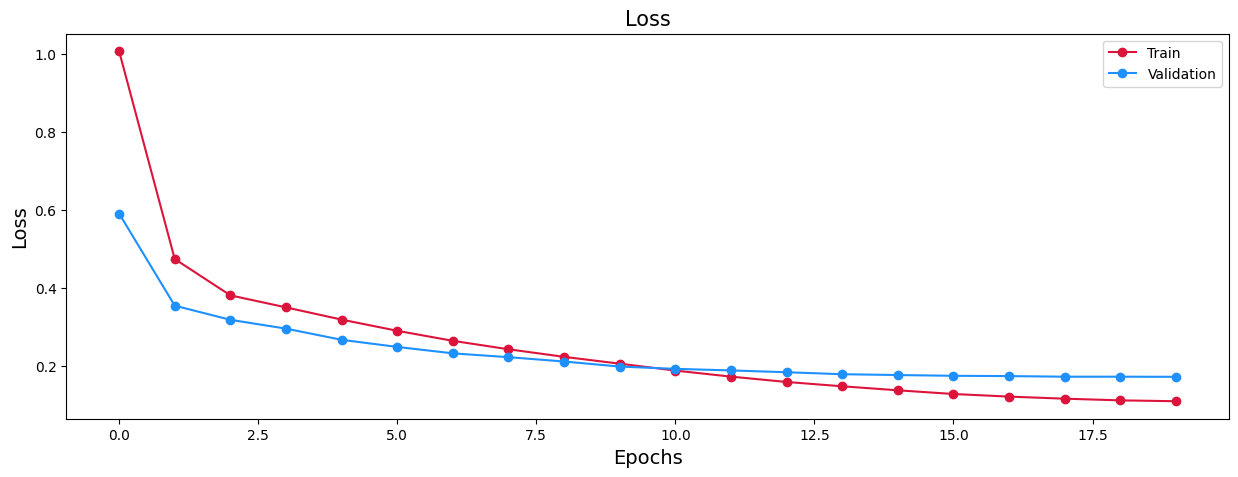

In [48]:
plot_training_history(history)

In [49]:
checkpoint = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)

test_metrics = evaluate(model, loaders["test"], criterion, device)
test_metrics

eval:   0%|          | 0/29 [00:00<?, ?it/s]

{'loss': 0.21063825745007086, 'accuracy': 0.9369607843137255}

In [50]:
@torch.no_grad()
def predict_dataloader(model: TransformerABSA, dataloader, device: torch.device) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_labels = []
    all_predictions = []
    for batch in tqdm(dataloader, desc="predict", leave=False):
        batch = move_batch_to_device(batch, device)
        logits = model(**model_inputs(batch))
        logits = model.reshape_logits(logits)
        predictions = logits.argmax(dim=-1)
        all_labels.append(batch["labels"].detach().cpu().numpy())
        all_predictions.append(predictions.detach().cpu().numpy())
    return np.concatenate(all_labels, axis=0), np.concatenate(all_predictions, axis=0)


y_test, y_pred = predict_dataloader(model, loaders["test"], device)
evaluator = ABSASklearnEvaluator(y_test, y_pred, aspect_category_names)
evaluator.report("aspect#category")

predict:   0%|          | 0/29 [00:00<?, ?it/s]

,precision,recall,f1-score,support
,0.954922,0.983330,0.968918,17816.000000
FACILITIES#CLEANLINESS,0.250000,0.200000,0.222222,5.000000
FACILITIES#COMFORT,1.000000,0.000000,0.000000,26.000000
FACILITIES#DESIGN&FEATURES,0.700000,0.323077,0.442105,65.000000
FACILITIES#GENERAL,0.600000,0.142857,0.230769,21.000000
FACILITIES#MISCELLANEOUS,1.000000,0.000000,0.000000,8.000000
FACILITIES#PRICES,1.000000,0.000000,0.000000,13.000000
FACILITIES#QUALITY,0.904762,0.372549,0.527778,51.000000
FOOD&DRINKS#MISCELLANEOUS,1.000000,0.000000,0.000000,3.000000
FOOD&DRINKS#PRICES,0.000000,0.000000,0.000000,9.000000


In [51]:
evaluator.report("aspect#category,polarity")


,precision,recall,f1-score,support
"FACILITIES#CLEANLINESS,None",0.993289,0.994958,0.994123,595.000000
"FACILITIES#CLEANLINESS,negative",1.000000,0.000000,0.000000,3.000000
"FACILITIES#CLEANLINESS,positive",0.000000,0.000000,0.000000,2.000000
"FACILITIES#COMFORT,None",0.956667,1.000000,0.977853,574.000000
"FACILITIES#COMFORT,negative",1.000000,0.000000,0.000000,6.000000
...,...,...,...,...
"SERVICE#GENERAL,neutral",0.000000,0.000000,0.000000,28.000000
"SERVICE#GENERAL,positive",0.928571,0.968481,0.948107,349.000000
accuracy,0.936961,0.936961,0.936961,0.936961
macro avg,0.846585,0.433813,0.438288,20400.000000


In [52]:
prediction_path = prediction_dir / f"{run_name}-notebook.txt"
save_absa_predictions(
    save_path=prediction_path,
    raw_texts=loaders["test"].dataset.raw_texts,
    encoded_review_labels=y_pred,
    aspect_category_names=aspect_category_names,
)
print(f"Saved predictions: {prediction_path}")


write predictions:   0%|          | 0/600 [00:00<?, ?it/s]

Saved predictions: /content/drive/MyDrive/bachnt/KHDL/predictions/vlsp-2018-hotel-e5-small-notebook.txt


In [56]:
@torch.no_grad()
def predict_texts(texts: str | list[str]) -> np.ndarray:
    if isinstance(texts, str):
        texts = [texts]
    model_texts = [active_text_preprocessor(text) for text in texts] if active_text_preprocessor else texts
    encoded = tokenizer(
        model_texts,
        max_length=max_length,
        padding=True,
        truncation=True,
        return_tensors="pt",
    )
    encoded = {key: value.to(device) for key, value in encoded.items()}
    logits = model(**encoded)
    logits = model.reshape_logits(logits)
    return logits.argmax(dim=-1).detach().cpu().numpy()


sample_predictions = predict_texts(["Dịch vụ tốt, ks sạch sẽ, vị trí thuận tiện. Hoàn toàn hài lòng!"])
sample_predictions


array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [57]:
model.print_acsa_pred(torch.tensor(sample_predictions[0]))

=> HOTEL#CLEANLINESS,positive
=> HOTEL#COMFORT,positive
=> HOTEL#GENERAL,positive
=> LOCATION#GENERAL,positive
